# Benchmark Comparativo de Modelos: Predição de Popularidade no Spotify
Pipeline de comparação entre algoritmos de **Regressão**, **Classificação**, **Clustering** e **Detecção de Anomalias**.

In [1]:
import os
import time
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, IsolationForest
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, accuracy_score, classification_report
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')

### 1. Carregamento e Preparação dos Dados

In [2]:
# Localização dinâmica do dataset
data_path = 'data/dataset.csv' if os.path.exists('data/dataset.csv') else ('../data/dataset.csv' if os.path.exists('../data/dataset.csv') else 'dataset.csv')
df = pd.read_csv(data_path)

# Limpeza inicial
df = df.drop(columns=[df.columns[0], 'track_id'])
df = df.dropna(subset=['artists', 'track_name', 'album_name'])

X = df.drop(columns=['popularity'])
y = df['popularity']

# Divisão dos dados: 10% Teste Final, 81% Treino, 9% Validação
X_desenvolvimento, X_teste_final, y_desenvolvimento, y_teste_final = train_test_split(
    X, y, test_size=0.10, random_state=42
)
X_treino, X_validacao, y_treino, y_validacao = train_test_split(
    X_desenvolvimento, y_desenvolvimento, test_size=0.10, random_state=42
)

print(f"Treino: {X_treino.shape[0]} amostras | Validação: {X_validacao.shape[0]} amostras | Teste Final: {X_teste_final.shape[0]} amostras")

Treino: 92339 amostras | Validação: 10260 amostras | Teste Final: 11400 amostras


### 2. Feature Engineering (Target Encoding OOF)

In [3]:
numeric_features = [
    'duration_ms', 'danceability', 'energy', 'key', 'loudness', 'mode',
    'speechiness', 'acousticness', 'instrumentalness', 'liveness',
    'valence', 'tempo', 'time_signature'
]
features_audio = numeric_features + ['explicit']

X_train_final = X_treino[features_audio].copy()
X_val_final = X_validacao[features_audio].copy()

X_train_final['explicit'] = X_treino['explicit'].astype(int)
X_val_final['explicit'] = X_validacao['explicit'].astype(int)

global_mean = y_treino.mean()

# 1. Target Encoding para Gênero
genre_means = y_treino.groupby(X_treino['track_genre']).mean()
X_train_final['genre_encoded'] = X_treino['track_genre'].map(genre_means).fillna(global_mean)
X_val_final['genre_encoded'] = X_validacao['track_genre'].map(genre_means).fillna(global_mean)

# 2. Target Encoding Out-Of-Fold para Artista (K=5)
X_train_final['artist_encoded'] = global_mean
kf = KFold(n_splits=5, shuffle=True, random_state=42)

for train_idx, val_idx in kf.split(X_treino):
    X_tr_fold, X_val_fold = X_treino.iloc[train_idx], X_treino.iloc[val_idx]
    y_tr_fold = y_treino.iloc[train_idx]
    
    artist_means_fold = y_tr_fold.groupby(X_tr_fold['artists']).mean()
    X_train_final.iloc[val_idx, X_train_final.columns.get_loc('artist_encoded')] = \
        X_val_fold['artists'].map(artist_means_fold).fillna(global_mean).values

# Mapeamento do artista na Validação com média do Treino completo
artist_means_full_train = y_treino.groupby(X_treino['artists']).mean()
X_val_final['artist_encoded'] = X_validacao['artists'].map(artist_means_full_train).fillna(global_mean)

X_train_final.head()

### 3. Comparação dos Modelos de Regressão

In [4]:
modelos_regressao = {
    'Regressão Linear (Baseline)': LinearRegression(),
    'Árvore de Decisão': DecisionTreeRegressor(max_depth=10, random_state=42),
    'Random Forest (Bagging)': RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'XGBoost (Boosting)': XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42, n_jobs=-1),
    'LightGBM (Boosting)': LGBMRegressor(n_estimators=100, learning_rate=0.1, random_state=42, n_jobs=-1, verbose=-1)
}

resultados = []
previsoes_modelos = {}

print("Treinando e avaliando modelos de regressão...\n")
for nome, modelo in modelos_regressao.items():
    inicio = time.time()
    modelo.fit(X_train_final, y_treino)
    tempo_treino = time.time() - inicio
    
    preds = modelo.predict(X_val_final)
    previsoes_modelos[nome] = preds
    
    mae = mean_absolute_error(y_validacao, preds)
    rmse = np.sqrt(mean_squared_error(y_validacao, preds))
    r2 = r2_score(y_validacao, preds)
    
    resultados.append({
        'Modelo': nome,
        'MAE': mae,
        'RMSE': rmse,
        'R²': r2,
        'R² (%)': f"{r2 * 100:.2f}%",
        'Tempo (s)': round(tempo_treino, 2)
    })

df_comparativo = pd.DataFrame(resultados).sort_values(by='MAE', ascending=True).reset_index(drop=True)
display(df_comparativo)

Treinando e avaliando modelos de regressão...



,Modelo,MAE,RMSE,R²,R² (%),Tempo (s)
0,Random Forest (Bagging),8.061284,13.386150,0.642403,64.24%,17.31
1,XGBoost (Boosting),8.633612,13.775617,0.621292,62.13%,0.54
2,LightGBM (Boosting),8.695174,13.836301,0.617948,61.79%,0.48
3,Árvore de Decisão,8.798666,14.424891,0.584753,58.48%,0.62
4,Regressão Linear (Baseline),9.686953,14.616246,0.573662,57.37%,0.04


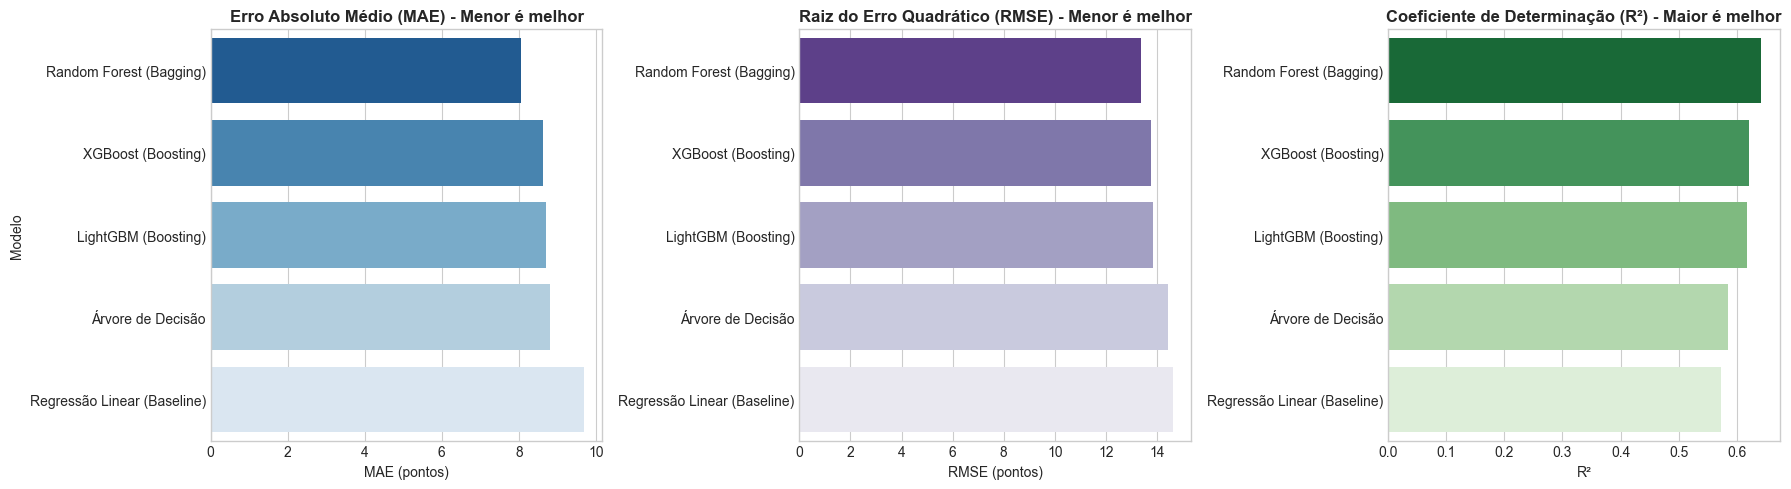

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.barplot(data=df_comparativo, x='MAE', y='Modelo', ax=axes[0], palette='Blues_r')
axes[0].set_title('Erro Absoluto Médio (MAE) - Menor é melhor', fontsize=12, fontweight='bold')
axes[0].set_xlabel('MAE (pontos)')

sns.barplot(data=df_comparativo, x='RMSE', y='Modelo', ax=axes[1], palette='Purples_r')
axes[1].set_title('Raiz do Erro Quadrático (RMSE) - Menor é melhor', fontsize=12, fontweight='bold')
axes[1].set_xlabel('RMSE (pontos)')
axes[1].set_ylabel('')

sns.barplot(data=df_comparativo, x='R²', y='Modelo', ax=axes[2], palette='Greens_r')
axes[2].set_title('Coeficiente de Determinação (R²) - Maior é melhor', fontsize=12, fontweight='bold')
axes[2].set_xlabel('R²')
axes[2].set_ylabel('')

plt.tight_layout()
plt.show()

### 4. Classificação: Regressão Logística (Previsão de Hits >= 50)

In [6]:
y_train_hit = (y_treino >= 50).astype(int)
y_val_hit = (y_validacao >= 50).astype(int)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_final)
X_val_scaled = scaler.transform(X_val_final)

modelo_logreg = LogisticRegression(max_iter=1000, random_state=42)
modelo_logreg.fit(X_train_scaled, y_train_hit)

preds_hit = modelo_logreg.predict(X_val_scaled)

print(f"Acurácia Geral: {accuracy_score(y_val_hit, preds_hit):.2%}\n")
print(classification_report(y_val_hit, preds_hit, target_names=['Não Hit (<50)', 'Hit (>=50)']))

Acurácia Geral: 84.56%

               precision    recall  f1-score   support

Não Hit (<50)       0.86      0.94      0.90      7649
   Hit (>=50)       0.76      0.57      0.65      2611

     accuracy                           0.85     10260
    macro avg       0.81      0.75      0.78     10260
 weighted avg       0.84      0.85      0.84     10260



### 5. Clustering: K-Means (Segmentação Musical)

In [7]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init='auto')
clusters_treino = kmeans.fit_predict(X_train_scaled)

df_clusters = X_train_final.copy()
df_clusters['cluster'] = clusters_treino
df_clusters['popularity'] = y_treino.values

resumo_clusters = df_clusters.groupby('cluster').agg({
    'popularity': 'mean',
    'danceability': 'mean',
    'energy': 'mean',
    'acousticness': 'mean',
    'loudness': 'mean',
    'tempo': 'mean'
}).rename(columns={'popularity': 'popularidade_media'}).reset_index()

print("=== PERFIL MÉDIO DOS CLUSTERS SÔNICOS ===")
display(resumo_clusters.round(2))

=== PERFIL MÉDIO DOS CLUSTERS SÔNICOS ===


,cluster,popularidade_media,danceability,energy,acousticness,loudness,tempo
0,0,33.68,0.58,0.72,0.21,-6.61,126.22
1,1,29.42,0.44,0.27,0.78,-15.27,108.97
2,2,36.09,0.64,0.72,0.23,-6.60,121.51
3,3,34.39,0.60,0.74,0.18,-6.60,125.04


### 6. Detecção de Anomalias: Isolation Forest

In [8]:
iso_forest = IsolationForest(contamination=0.05, random_state=42, n_jobs=-1)
outliers = iso_forest.fit_predict(X_train_final)

qtd_normais = (outliers == 1).sum()
qtd_anomalias = (outliers == -1).sum()

print("=== DETECÇÃO DE ANOMALIAS (ISOLATION FOREST) ===")
print(f"Músicas Típicas:   {qtd_normais} ({qtd_normais / len(outliers):.1%}) | Média Popularidade: {y_treino[outliers == 1].mean():.2f}")
print(f"Músicas Atípicas:  {qtd_anomalias} ({qtd_anomalias / len(outliers):.1%})  | Média Popularidade: {y_treino[outliers == -1].mean():.2f}")

=== DETECÇÃO DE ANOMALIAS (ISOLATION FOREST) ===
Músicas Típicas:   87722 (95.0%) | Média Popularidade: 33.66
Músicas Atípicas:  4617 (5.0%)  | Média Popularidade: 25.98
